In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [29]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from multiprocessing import Pool
import importlib
import helpers
importlib.reload(helpers)
from helpers import encoding, ideal_syndrome_meas, ideal_recovery, logical_msd_all_errors, logical_msd_no_errors

# Defining Global Variable

In [3]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))

# Qubit labeling of the Steane Code

Qubits are ordered from top to down, left to right, increasingly

The logical operators act on the left side of the triangle

# Infidelity to error rates

In [4]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [5]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [6]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Testing syndrome measurements and recovery

In [ ]:
# Prepare the ideal encoded magic state for comparison.
ideal = QuantumCircuit(7)
ideal.ry(theta, 0)
encoding(ideal, 0)
ideal_sv = Statevector.from_instruction(ideal)

# Create a 10-qubit circuit: 7 data qubits plus 3 syndrome ancillas.
test = QuantumCircuit(10)

# Classical registers for X- and Z-type syndrome outcomes.
x_syndrome = ClassicalRegister(3)
z_syndrome = ClassicalRegister(3)

test.add_register(x_syndrome, z_syndrome)

# Encode the input state into the Steane code.
encoding(test, 0)

# Insert test errors.
test.z(6)
test.x(4)

# Measure syndromes and apply the corresponding recovery operation.
ideal_syndrome_meas(test, 0, 7, x_syndrome, z_syndrome)
ideal_recovery(test, 0, x_syndrome, z_syndrome)

# Run a noiseless statevector simulation.
noise_model = NoiseModel()
meas_circuit_noise = test.copy()
meas_circuit_noise.append(
    SaveStatevector(
        num_qubits=10,
        label="state_post",
        conditional=True,
        pershot=True
    ),
    meas_circuit_noise.qubits
)

backend = AerSimulator(noise_model=noise_model)
job = backend.run(meas_circuit_noise, shots=1)
result = job.result()

# Print the saved statevectors grouped by syndrome outcome.
res_statevectors = result.data()['state_post']
print(res_statevectors)

{'0x14': [Statevector([ 0.35355339+0.j,  0.        +0.j,  0.        +0.j, ...,
             -0.        +0.j, -0.        +0.j, -0.        +0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2))]}


In [ ]:
red_sv = partial_trace(res_statevectors['0x14'][0], list(range(7,10)))
print(state_fidelity(ideal_sv, red_sv))

0.9999999999999997


# Finding probability of success

In [ ]:
circuit = QuantumCircuit(21,14)

# Logical MSD circuit
for i in [0,7,14]:
    circuit.ry(theta, i)
encoding(circuit, 0)
encoding(circuit, 7)
encoding(circuit, 14)
 
for i in range(7):
    circuit.cz(i, i+7)
    circuit.h(i+14)

for i in range(7):
    circuit.cz(i+7, i+14)
    
for i in range(14):
    circuit.h(i)

In [ ]:
# Number of shots used to estimate the success probability.
shots = 1_000

# Run the circuit without additional noise.
noise_model = NoiseModel()
meas_circuit_noise = circuit.copy()

# Measure the 14 data qubits into the 14 classical bits.
meas_circuit_noise.measure([i for i in range(14)], [i for i in range(14)]) 

backend = AerSimulator(noise_model=noise_model)
job = backend.run(meas_circuit_noise, shots=shots)
result = job.result()

counts = result.get_counts()

# Count shots whose two Steane blocks have trivial syndrome
# and the expected logical parity.
correct = 0

for key, values in counts.items():
    # Split the measured bitstring into the two 7-qubit blocks.
    block1_syndrome = str(key)[0:7]
    block2_syndrome = str(key)[7:14]
    
    # Compute the three stabilizer parities and logical parity for block 1.
    block1_parity1 = (
        int(block1_syndrome[-1]) + int(block1_syndrome[-2])
        + int(block1_syndrome[-3]) + int(block1_syndrome[-4])
    ) % 2

    block1_parity2 = (
        int(block1_syndrome[-2]) + int(block1_syndrome[-3])
        + int(block1_syndrome[-5]) + int(block1_syndrome[-6])
    ) % 2

    block1_parity3 = (
        int(block1_syndrome[-3]) + int(block1_syndrome[-4])
        + int(block1_syndrome[-6]) + int(block1_syndrome[-7])
    ) % 2

    block1_logical_op = (
        int(block1_syndrome[-1]) + int(block1_syndrome[-2])
        + int(block1_syndrome[-5])
    ) % 2 
    
    # Compute the three stabilizer parities and logical parity for block 2.
    block2_parity1 = (
        int(block2_syndrome[-1]) + int(block2_syndrome[-2])
        + int(block2_syndrome[-3]) + int(block2_syndrome[-4])
    ) % 2

    block2_parity2 = (
        int(block2_syndrome[-2]) + int(block2_syndrome[-3])
        + int(block2_syndrome[-5]) + int(block2_syndrome[-6])
    ) % 2

    block2_parity3 = (
        int(block2_syndrome[-3]) + int(block2_syndrome[-4])
        + int(block2_syndrome[-6]) + int(block2_syndrome[-7])
    ) % 2

    block2_logical_op = (
        int(block2_syndrome[-1]) + int(block2_syndrome[-2])
        + int(block2_syndrome[-5])
    ) % 2
    
    # A shot is correct if both blocks have trivial stabilizer syndrome
    # and the expected logical parity.
    parity_list = [
        block1_parity1,
        block1_parity2,
        block1_parity3,
        block1_logical_op,
        block2_parity1,
        block2_parity2,
        block2_parity3,
        block2_logical_op
    ]

    if parity_list == [0, 0, 0, 0, 0, 0, 0, 0]:
        correct += values

print(f"Probability of measuring correct outputs: {correct / shots * 100}%")

Probability of measuring correct outputs: 41.4%


# Fidelity Simulations

Case: Logical MSD with all errors

In [63]:
# Initializing lists for later calculations of average fidelity and uncertainty for each error probability
# Also keeping track of total shots 
sum_fid_all_errors_list = np.zeros(5, dtype=float)
accepted_all_errors_list = np.zeros(5, dtype=float)
total_shots_all_errors = 0

In [ ]:
# Can be ran multiple times
# Dividing into smaller batches to ensure memory doesn't run out
num_shots = 50
batch_shots = 25

for p in range(len(spam0)):
    for _ in range(num_shots//batch_shots):
        sumfid, accepted = logical_msd_all_errors(batch_shots, one_qubit_gate_error_prob[p], two_qubit_gate_error_prob[p], spam0[p], spam1[p])
    
        sum_fid_all_errors_list[p] += sumfid
        accepted_all_errors_list[p] += accepted
    
total_shots_all_errors = total_shots_all_errors + num_shots

In [23]:
# Saving the results
np.savez("logical_msd_all_errors.npz",
    sum_fid_list=sum_fid_all_errors_list,
    accepted_list=accepted_all_errors_list,
    total_shots=total_shots_all_errors
)

In [24]:
# Calculating the average fidelity and uncertainty per physical error rate
avg_fid_all_errors_list = []
avg_fid_all_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_all_errors_list[i]/accepted_all_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_all_errors_list[i])
    avg_fid_all_errors_list.append(avg_fid)
    avg_fid_all_errors_unc_list.append(avg_fid_unc)

Case: Logical MSD with no errors

In [25]:
# Initializing lists for later calculations of average fidelity and uncertainty for each error probability
# Also keeping track of total shots 
sum_fid_no_errors_list = np.array([0]*5) 
accepted_no_errors_list = np.array([0]*5)
total_shots_no_errors = 0

In [ ]:
# Can be ran multiple times
num_shots = 50

for p in range(len(spam0)):
    sumfid, accepted = logical_msd_no_errors(num_shots, one_qubit_gate_error_prob[p])
    
    sum_fid_no_errors_list[p] += sumfid
    accepted_no_errors_list[p] += accepted

total_shots_no_errors = total_shots_no_errors + num_shots

In [27]:
# Saving the results
np.savez("logical_msd_no_errors.npz",
    sum_fid_list=sum_fid_no_errors_list,
    accepted_list=accepted_no_errors_list,
    total_shots=total_shots_no_errors
)

In [28]:
# Calculating the average fidelity and uncertainty per physical error rate
avg_fid_no_errors_list = []
avg_fid_no_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_no_errors_list[i]/accepted_no_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_no_errors_list[i])
    avg_fid_no_errors_list.append(avg_fid)
    avg_fid_no_errors_unc_list.append(avg_fid_unc)

Case: Input infidelities

In [19]:
ideal_input = QuantumCircuit(1)
ideal_input.ry(theta,0)
ideal_input_dm = DensityMatrix.from_instruction(ideal_input)

In [20]:
input_avg_fid_list = []
num_shots = 1

for i in range(len(one_qubit_gate_error_prob)):
    input_circuit = QuantumCircuit(1)
    input_circuit.ry(theta, 0) 
    
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ["ry"])
    
    input_circuit.append(SaveDensityMatrix(num_qubits=1, label='dm_post', conditional=True, pershot=True), input_circuit.qubits)
    
    backend = AerSimulator(noise_model=nm, method='density_matrix')
    job = backend.run(input_circuit, shots=num_shots)
    result = job.result()

    res_dm = result.data()['dm_post']
    
    input_avg_fid_list.append(state_fidelity(ideal_input_dm, res_dm[''][0]))

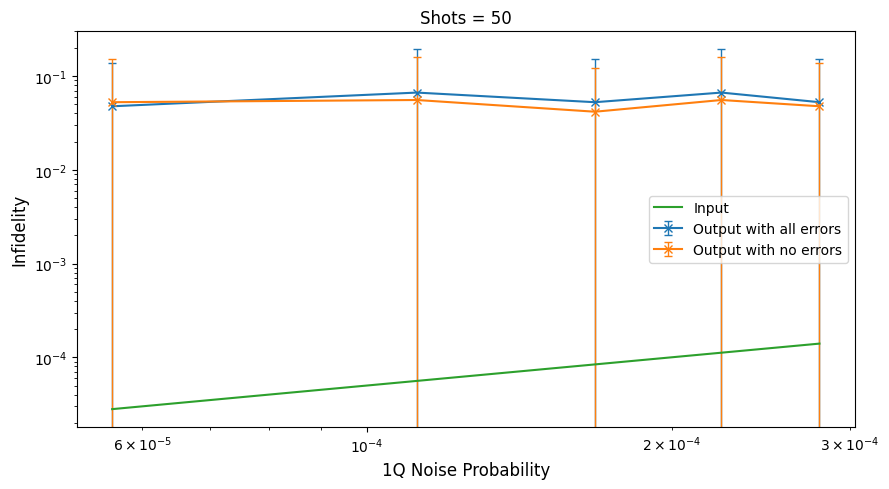

In [29]:
plt.figure(figsize=(9, 5))
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_all_errors_list],
    yerr=avg_fid_all_errors_unc_list,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Output with all errors'
)
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_no_errors_list],
    yerr=avg_fid_no_errors_unc_list,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Output with no errors'
)
plt.plot(one_qubit_gate_error_prob, [1-f for f in input_avg_fid_list], label='Input')

plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.title(f"Shots = {total_shots_all_errors}")
plt.tight_layout()
plt.legend()
plt.show()

# Loading data from cluster

In [7]:
data = np.load("cluster_logical_msd_all_errors.npz")
sum_fid_all_errors_list = data["sum_fid_list"]
accepted_all_errors_list = data["accepted_list"]
total_shots_all_errors = data["total_shots"].item()

In [8]:
data = np.load("cluster_logical_msd_no_errors.npz")
sum_fid_no_errors_list = data["sum_fid_list"]
accepted_no_errors_list = data["accepted_list"]
total_shots_no_errors = data["total_shots"].item()

In [9]:
data = np.load("cluster_logical_msd_meas_errors.npz")
sum_fid_meas_errors_list = data["sum_fid_list"]
accepted_meas_errors_list = data["accepted_list"]
total_shots_meas_errors = data["total_shots"].item()

In [10]:
data = np.load("cluster_logical_msd_2q_errors.npz")
sum_fid_2q_errors_list = data["sum_fid_list"]
accepted_2q_errors_list = data["accepted_list"]
total_shots_2q_errors = data["total_shots"].item()

In [11]:
data = np.load("cluster_logical_msd_1q_errors.npz")
sum_fid_1q_errors_list = data["sum_fid_list"]
accepted_1q_errors_list = data["accepted_list"]
total_shots_1q_errors = data["total_shots"].item()

In [12]:
print(total_shots_all_errors)
print(total_shots_no_errors)
print(total_shots_meas_errors)
print(total_shots_2q_errors)
print(total_shots_1q_errors)

220000
1800000
300000
100000
1500000


In [13]:
# Calculating the average fidelity and uncertainty per physical error rate
avg_fid_all_errors_list = []
avg_fid_all_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_all_errors_list[i]/accepted_all_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_all_errors_list[i])
    avg_fid_all_errors_list.append(avg_fid)
    avg_fid_all_errors_unc_list.append(avg_fid_unc)
    
avg_fid_no_errors_list = []
avg_fid_no_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_no_errors_list[i]/accepted_no_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_no_errors_list[i])
    avg_fid_no_errors_list.append(avg_fid)
    avg_fid_no_errors_unc_list.append(avg_fid_unc)
    
avg_fid_meas_errors_list = []
avg_fid_meas_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_meas_errors_list[i]/accepted_meas_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_meas_errors_list[i])
    avg_fid_meas_errors_list.append(avg_fid)
    avg_fid_meas_errors_unc_list.append(avg_fid_unc)
    
avg_fid_2q_errors_list = []
avg_fid_2q_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_2q_errors_list[i]/accepted_2q_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_2q_errors_list[i])
    avg_fid_2q_errors_list.append(avg_fid)
    avg_fid_2q_errors_unc_list.append(avg_fid_unc)
    
avg_fid_1q_errors_list = []
avg_fid_1q_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_1q_errors_list[i]/accepted_1q_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_1q_errors_list[i])
    avg_fid_1q_errors_list.append(avg_fid)
    avg_fid_1q_errors_unc_list.append(avg_fid_unc)

In [16]:
list1 = [1 - f for f in avg_fid_all_errors_list]
list2 = [1 - f for f in avg_fid_no_errors_list]
list3 = [1 - f for f in avg_fid_meas_errors_list]
list4 = [1 - f for f in avg_fid_2q_errors_list]
list5 = [1 - f for f in avg_fid_1q_errors_list]

output_error_rate_all_errors = inf_to_error(list1, 1)
output_error_rate_no_errors = inf_to_error(list2, 1)
output_error_rate_meas_errors = inf_to_error(list3, 1)
output_error_rate_2q_errors = inf_to_error(list4, 1)
output_error_rate_1q_errors = inf_to_error(list5, 1)

# Using data from cluster to plot

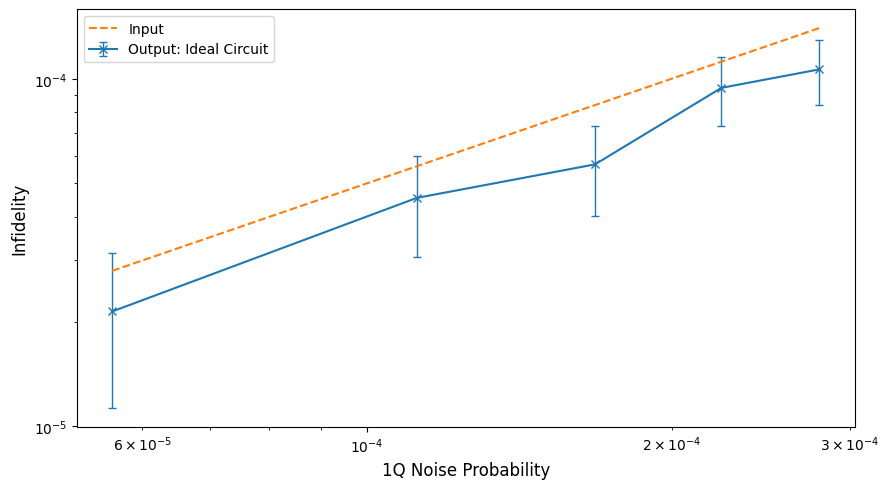

In [17]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_no_errors_list],
    yerr=avg_fid_no_errors_unc_list,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Output: Ideal Circuit'
)
plt.plot(one_qubit_gate_error_prob, [1-f for f in input_avg_fid_list], label='Input', linestyle='--')

plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()

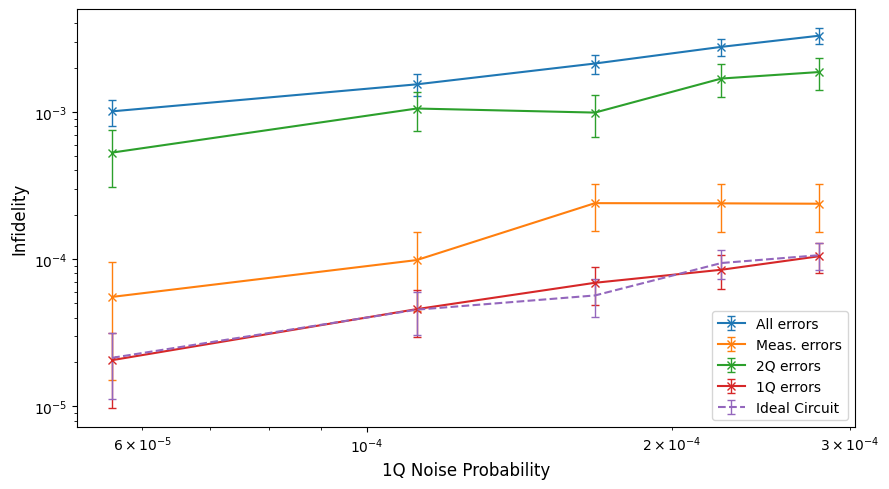

In [19]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_all_errors_list],
    yerr=avg_fid_all_errors_unc_list,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='All errors'
)
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_meas_errors_list],
    yerr=avg_fid_meas_errors_unc_list,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='Meas. errors'
)
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_2q_errors_list],
    yerr=avg_fid_2q_errors_unc_list,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='2Q errors'
)
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_1q_errors_list],
    yerr=avg_fid_1q_errors_unc_list,
    fmt=f'x-',
    capsize=3,
    elinewidth=1,
    label='1Q errors'
)
plt.errorbar(
    one_qubit_gate_error_prob,
    [1-f for f in avg_fid_no_errors_list],
    yerr=avg_fid_no_errors_unc_list,
    fmt=f'--',
    capsize=3,
    elinewidth=1,
    label='Ideal Circuit'
)

plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()

In [15]:
# --- APS-style global settings ---
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

Text(0.0, 1.0, '(b)')

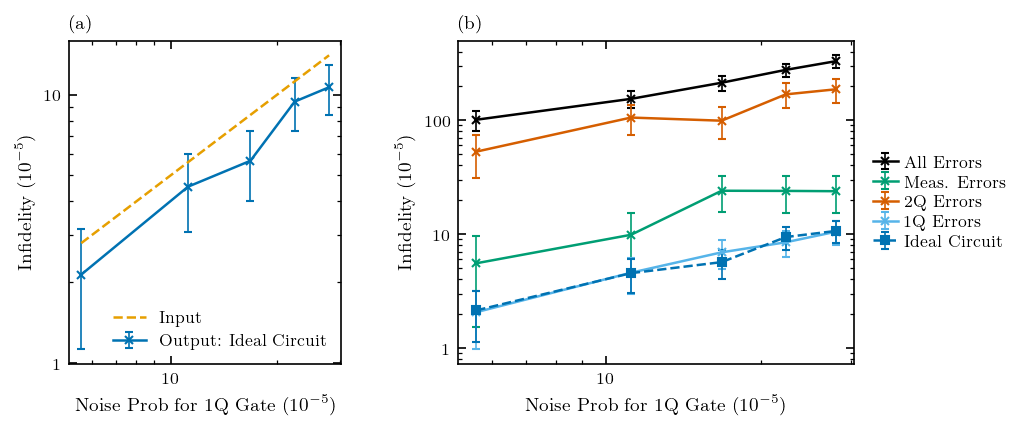

In [22]:
fig = plt.figure(figsize=(6.75, 2.8))
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.45], wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Plot 1 ───────────────────────────────────────────────
scale = 1e-5

ax1.errorbar(one_qubit_gate_error_prob,
             [1-f for f in avg_fid_no_errors_list],
             yerr=avg_fid_no_errors_unc_list,
             fmt='x', linestyle='-', capsize=2, elinewidth=0.8,
             color='#0072B2', markersize=4, label='Output: Ideal Circuit')
ax1.plot(one_qubit_gate_error_prob,
         [1-f for f in input_avg_fid_list],
         linestyle='--', color='#E69F00', label='Input')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/scale:g}'))
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/scale:g}'))
ax1.xaxis.set_minor_formatter(NullFormatter())
ax1.yaxis.set_minor_formatter(NullFormatter())
ax1.tick_params(which='both', direction='in', top=True, right=True)
ax1.tick_params(which='major', length=4)
ax1.tick_params(which='minor', length=2)
ax1.legend(frameon=False, loc='lower right')
ax1.set_ylabel(r'Infidelity ($10^{-5}$)')
ax1.set_xlabel(r'Noise Prob for 1Q Gate ($10^{-5}$)')
ax1.set_title('(a)', loc='left', fontsize=9)

# ── Plot 2 ───────────────────────────────────────────────
xscale = yscale = 1e-5

# (color, linestyle, label, y_data, yerr)
series = [
    ('#000000', 'all_errors',    [1-f for f in avg_fid_all_errors_list],  avg_fid_all_errors_unc_list),
    ('#009E73', 'meas_errors',   [1-f for f in avg_fid_meas_errors_list], avg_fid_meas_errors_unc_list),
    ('#D55E00', '2q_errors',     [1-f for f in avg_fid_2q_errors_list],   avg_fid_2q_errors_unc_list),
    ('#56B4E9', '1q_errors',     [1-f for f in avg_fid_1q_errors_list],   avg_fid_1q_errors_unc_list),
    ('#0072B2', 'ideal_circuit', [1-f for f in avg_fid_no_errors_list],   avg_fid_no_errors_unc_list),
]
labels = ['All Errors', 'Meas. Errors', '2Q Errors', '1Q Errors', 'Ideal Circuit']
fmts   = ['x', 'x', 'x', 'x', 's']          # different markers per series
lss    = ['-', '-', '-', '-', '--']           # dashed for ideal

for (color, _, y, yerr), label, fmt, ls in zip(series, labels, fmts, lss):
    ax2.errorbar(one_qubit_gate_error_prob, y, yerr=yerr,
                 fmt=fmt, linestyle=ls, color=color,
                 capsize=2, elinewidth=0.8, markersize=4, label=label)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/xscale:g}'))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/yscale:g}'))
ax2.xaxis.set_minor_formatter(NullFormatter())
ax2.yaxis.set_minor_formatter(NullFormatter())
ax2.tick_params(which='both', direction='in', top=True, right=True)
ax2.tick_params(which='major', length=4)
ax2.tick_params(which='minor', length=2)
ax2.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False,
           handlelength=1.5, handletextpad=0.4, labelspacing=0.3)
ax2.set_ylabel(r'Infidelity ($10^{-5}$)')
ax2.set_xlabel(r'Noise Prob for 1Q Gate ($10^{-5}$)')
ax2.set_title('(b)', loc='left', fontsize=9)

# Calculating Infidelity Contributions

In [23]:
sum_c_list = []
for i in range(len(one_qubit_gate_error_prob)):
    sum_c_list.append(output_error_rate_meas_errors[i] + output_error_rate_2q_errors[i] + output_error_rate_1q_errors[i])

one_qubit_contributions = 0
two_qubit_contributions = 0
measurement_contributions = 0
for i, e in enumerate(one_qubit_gate_error_prob):
    print(f"For 1Q error probability = {e}")
    print(f"1Q Fractions = {output_error_rate_1q_errors[i] / sum_c_list[i]}")
    print(f"2Q Fractions = {output_error_rate_2q_errors[i] / sum_c_list[i]}")
    print(f"Measurement Fractions = {output_error_rate_meas_errors[i] / sum_c_list[i]}")
    print("")
    one_qubit_contributions += output_error_rate_1q_errors[i] / sum_c_list[i]
    two_qubit_contributions += output_error_rate_2q_errors[i] / sum_c_list[i]
    measurement_contributions += output_error_rate_meas_errors[i] / sum_c_list[i]

one_qubit_contributions /= len(one_qubit_gate_error_prob)
two_qubit_contributions /= len(one_qubit_gate_error_prob)
measurement_contributions /= len(one_qubit_gate_error_prob)

For 1Q error probability = 5.6e-05
1Q Fractions = 0.03406604819597502
2Q Fractions = 0.8743707274036634
Measurement Fractions = 0.09156322440036153

For 1Q error probability = 0.000112
1Q Fractions = 0.03820811867166575
2Q Fractions = 0.8795329193225428
Measurement Fractions = 0.08225896200579136

For 1Q error probability = 0.000168
1Q Fractions = 0.05323006537687142
2Q Fractions = 0.7618632035308082
Measurement Fractions = 0.1849067310923204

For 1Q error probability = 0.000224
1Q Fractions = 0.042179095812694814
2Q Fractions = 0.8386955670443529
Measurement Fractions = 0.1191253371429523

For 1Q error probability = 0.00028
1Q Fractions = 0.04744221452507278
2Q Fractions = 0.844821086616874
Measurement Fractions = 0.10773669885805313



In [25]:
print(one_qubit_contributions)
print(two_qubit_contributions)
print(measurement_contributions)

0.043025108516455954
0.8398567007836482
0.11711819069989574


# Final Plot

Text(0.0, 1.0, '(b)')

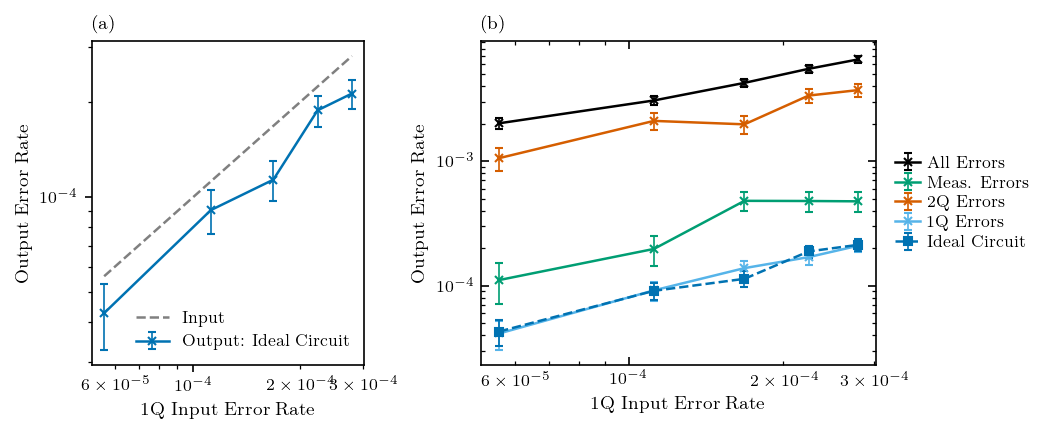

In [26]:
fig = plt.figure(figsize=(6.75, 2.8))
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.45], wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Plot 1 ───────────────────────────────────────────────
scale = 1e-5

ax1.errorbar(one_qubit_gate_error_prob,
             output_error_rate_no_errors,
             yerr=avg_fid_no_errors_unc_list,
             fmt='x', linestyle='-', capsize=2, elinewidth=0.8,
             color='#0072B2', markersize=4, label='Output: Ideal Circuit')
ax1.plot(one_qubit_gate_error_prob,
         one_qubit_gate_error_prob,
         linestyle='--', color='gray', label='Input')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend(frameon=False, loc='lower right')
ax1.set_ylabel("Output Error Rate")
ax1.set_xlabel("1Q Input Error Rate")
ax1.set_title('(a)', loc='left', fontsize=9)

# ── Plot 2 ───────────────────────────────────────────────
# (color, linestyle, label, y_data, yerr)
series = [
    ('#000000', 'all_errors',    output_error_rate_all_errors,  avg_fid_all_errors_unc_list),
    ('#009E73', 'meas_errors',   output_error_rate_meas_errors, avg_fid_meas_errors_unc_list),
    ('#D55E00', '2q_errors',     output_error_rate_2q_errors,   avg_fid_2q_errors_unc_list),
    ('#56B4E9', '1q_errors',     output_error_rate_1q_errors,   avg_fid_1q_errors_unc_list),
    ('#0072B2', 'ideal_circuit', output_error_rate_no_errors,   avg_fid_no_errors_unc_list),
]
labels = ['All Errors', 'Meas. Errors', '2Q Errors', '1Q Errors', 'Ideal Circuit']
fmts   = ['x', 'x', 'x', 'x', 's']          # different markers per series
lss    = ['-', '-', '-', '-', '--']           # dashed for ideal

for (color, _, y, yerr), label, fmt, ls in zip(series, labels, fmts, lss):
    ax2.errorbar(one_qubit_gate_error_prob, y, yerr=yerr,
                 fmt=fmt, linestyle=ls, color=color,
                 capsize=2, elinewidth=0.8, markersize=4, label=label)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.tick_params(which='both', direction='in', top=True, right=True)
ax2.tick_params(which='major', length=4)
ax2.tick_params(which='minor', length=2)
ax2.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False,
           handlelength=1.5, handletextpad=0.4, labelspacing=0.3)
ax2.set_ylabel("Output Error Rate")
ax2.set_xlabel("1Q Input Error Rate")
ax2.set_title('(b)', loc='left', fontsize=9)

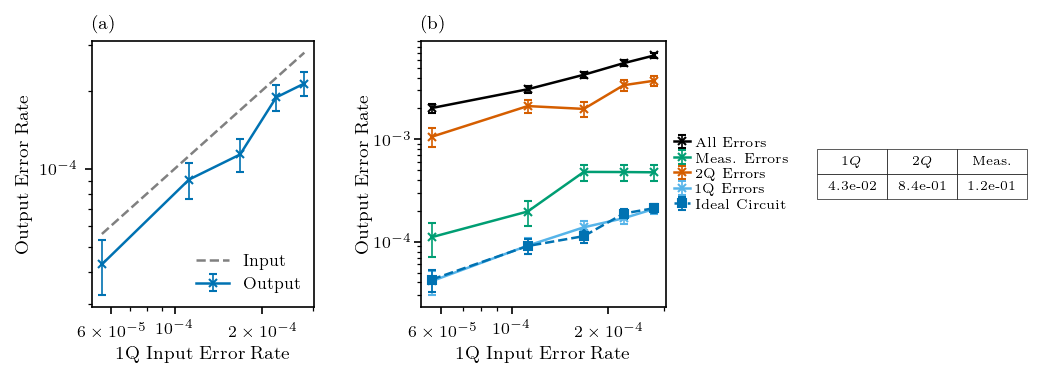

In [37]:
fig = plt.figure(figsize=(6.75, 2.65))

# Layout:
# plot 1 | spacer | plot 2 | legend | spacer | table
gs = GridSpec(
    1, 6,
    figure=fig,
    width_ratios=[1.0, 0.45, 1.10, 0.62, 0.08, 0.82],
    wspace=0.02
)

ax1 = fig.add_subplot(gs[0])
ax_spacer_12 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax_leg = fig.add_subplot(gs[3])
ax_spacer_lt = fig.add_subplot(gs[4])
ax_table = fig.add_subplot(gs[5])

ax_spacer_12.axis('off')
ax_spacer_lt.axis('off')
ax_leg.axis('off')
ax_table.axis('off')

# ── Plot 1 ───────────────────────────────────────────────
ax1.errorbar(
    one_qubit_gate_error_prob,
    output_error_rate_no_errors,
    yerr=avg_fid_no_errors_unc_list,
    fmt='x',
    linestyle='-',
    capsize=2,
    elinewidth=0.8,
    color='#0072B2',
    markersize=4,
    label='Output'
)

ax1.plot(
    one_qubit_gate_error_prob,
    one_qubit_gate_error_prob,
    linestyle='--',
    color='gray',
    label='Input'
)

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xticks([6e-5, 1e-4, 2e-4])
ax1.set_xticklabels([r'$6\times10^{-5}$', r'$10^{-4}$', r'$2\times10^{-4}$'])
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())

ax1.legend(frameon=False, loc='lower right')
ax1.set_ylabel("Output Error Rate")
ax1.set_xlabel("1Q Input Error Rate")
ax1.set_title('(a)', loc='left', fontsize=9)

# ── Plot 2 ───────────────────────────────────────────────
series = [
    ('#000000', output_error_rate_all_errors,  avg_fid_all_errors_unc_list),
    ('#009E73', output_error_rate_meas_errors, avg_fid_meas_errors_unc_list),
    ('#D55E00', output_error_rate_2q_errors,   avg_fid_2q_errors_unc_list),
    ('#56B4E9', output_error_rate_1q_errors,   avg_fid_1q_errors_unc_list),
    ('#0072B2', output_error_rate_no_errors,   avg_fid_no_errors_unc_list),
]

labels = [
    'All Errors',
    'Meas. Errors',
    '2Q Errors',
    '1Q Errors',
    'Ideal Circuit'
]

fmts = ['x', 'x', 'x', 'x', 's']
lss  = ['-', '-', '-', '-', '--']

for (color, y, yerr), label, fmt, ls in zip(series, labels, fmts, lss):
    ax2.errorbar(
        one_qubit_gate_error_prob,
        y,
        yerr=yerr,
        fmt=fmt,
        linestyle=ls,
        color=color,
        capsize=2,
        elinewidth=0.8,
        markersize=4,
        label=label
    )

ax2.set_xscale('log')
ax2.set_yscale('log')

ax2.set_xticks([6e-5, 1e-4, 2e-4])
ax2.set_xticklabels([r'$6\times10^{-5}$', r'$10^{-4}$', r'$2\times10^{-4}$'])
ax2.xaxis.set_minor_formatter(mticker.NullFormatter())

ax2.set_ylabel("Output Error Rate")
ax2.set_xlabel("1Q Input Error Rate")
ax2.set_title('(b)', loc='left', fontsize=9)

# Make plot 2 y-axis compact
ax2.yaxis.labelpad = 1
ax2.tick_params(axis='y', which='both', pad=1)

# ── Legend to the right of Plot 2 ─────────────────────────
handles, legend_labels = ax2.get_legend_handles_labels()

ax_leg.legend(
    handles,
    legend_labels,
    loc='center left',
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.25,
    borderaxespad=0.0
)

# ── Table to the right of the legend ──────────────────────
table_data = [
    [r'$1Q$', r'$2Q$', r'Meas.'],
    [
        f'{one_qubit_contributions:.1e}',
        f'{two_qubit_contributions:.1e}',
        f'{measurement_contributions:.1e}'
    ]
]

table = ax_table.table(
    cellText=table_data,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(6.2)
table.scale(1.15, 1.15)

for cell in table.get_celld().values():
    cell.set_linewidth(0.3)

# Compact APS-style margins
fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.23,
    top=0.90
)

plt.show()